In [ ]:
!pip install pandas numpy matplotlib openpyxl statsmodels --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

plt.rcParams.update({"figure.figsize":(16,5),"axes.grid":True})


In [ ]:
from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
print("File Loaded:", file_name)


Saving BDM-DATASET.xlsx to BDM-DATASET.xlsx
File Loaded: BDM-DATASET.xlsx


In [ ]:
xls = pd.ExcelFile(file_name)

preferred = ['Master_Sales_data','Product _Sales_MonthWise','Inventory_Data','Product_List']
frames = []

for sheet in preferred:
    if sheet in xls.sheet_names:
        df = pd.read_excel(file_name, sheet_name=sheet)
        frames.append(df)

sales_raw = pd.concat(frames, ignore_index=True).copy()
sales_raw.columns = [str(c).strip() for c in sales_raw.columns]


In [ ]:
# Detect columns
date_col = None
for c in sales_raw.columns:
    if "date" in c.lower() or "month" in c.lower():
        date_col = c
        break

qty_col = None
for c in sales_raw.columns:
    if "qty" in c.lower() or "quantity" in c.lower() or "sold" in c.lower():
        qty_col = c
        break

product_col = None
for c in sales_raw.columns:
    if "product" in c.lower() or "item" in c.lower() or "name" in c.lower():
        product_col = c
        break

sales = sales_raw[[date_col, product_col, qty_col]].copy()
sales.columns = ["Date","Product","Quantity"]
sales["Date"] = pd.to_datetime(sales["Date"], errors="coerce")
sales["Quantity"] = pd.to_numeric(sales["Quantity"], errors="coerce").fillna(0)
sales = sales.dropna(subset=["Date"])


In [ ]:
monthly_sales = sales.set_index("Date").resample("MS")["Quantity"].sum()
monthly_sales.head()


,Quantity
Date,
2024-01-01,81.0
2024-02-01,38.0
2024-03-01,65.0
2024-04-01,65.0
2024-05-01,70.0


#ABC classification

In [ ]:
prod_sum = sales.groupby("Product")["Quantity"].sum().sort_values(ascending=False).reset_index()
prod_sum["cum_pct"] = prod_sum["Quantity"].cumsum() / prod_sum["Quantity"].sum() * 100

def abc(p):
    if p <= 70: return "A"
    elif p <= 90: return "B"
    else: return "C"

prod_sum["Class"] = prod_sum["cum_pct"].apply(abc)
prod_sum.head()



,Product,Quantity,cum_pct,Class
0,P023,63.0,3.752233,A
1,P039,56.0,7.087552,A
2,P011,56.0,10.422871,A
3,P018,56.0,13.758189,A
4,P016,54.0,16.974390,A


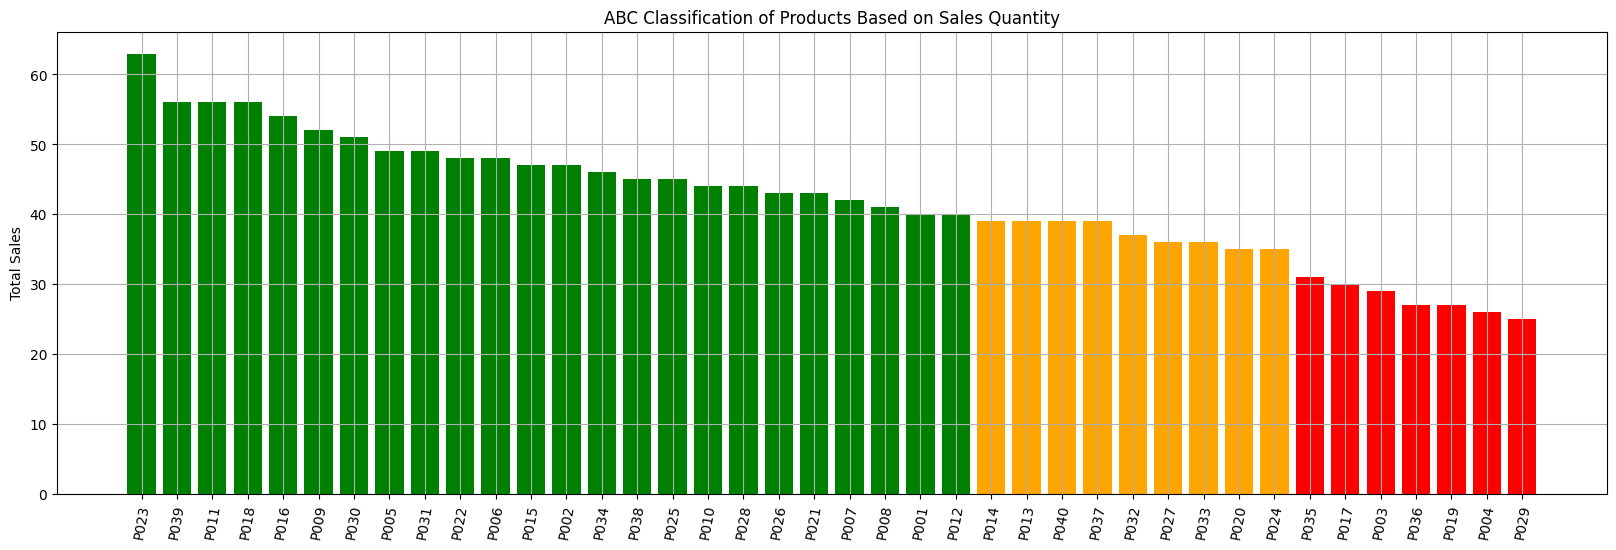

In [ ]:
colors = prod_sum["Class"].map({"A":"green","B":"orange","C":"red"})

plt.figure(figsize=(20,6))
plt.bar(prod_sum["Product"], prod_sum["Quantity"], color=colors)
plt.xticks(rotation=80)
plt.title("ABC Classification of Products Based on Sales Quantity")
plt.ylabel("Total Sales")
plt.show()


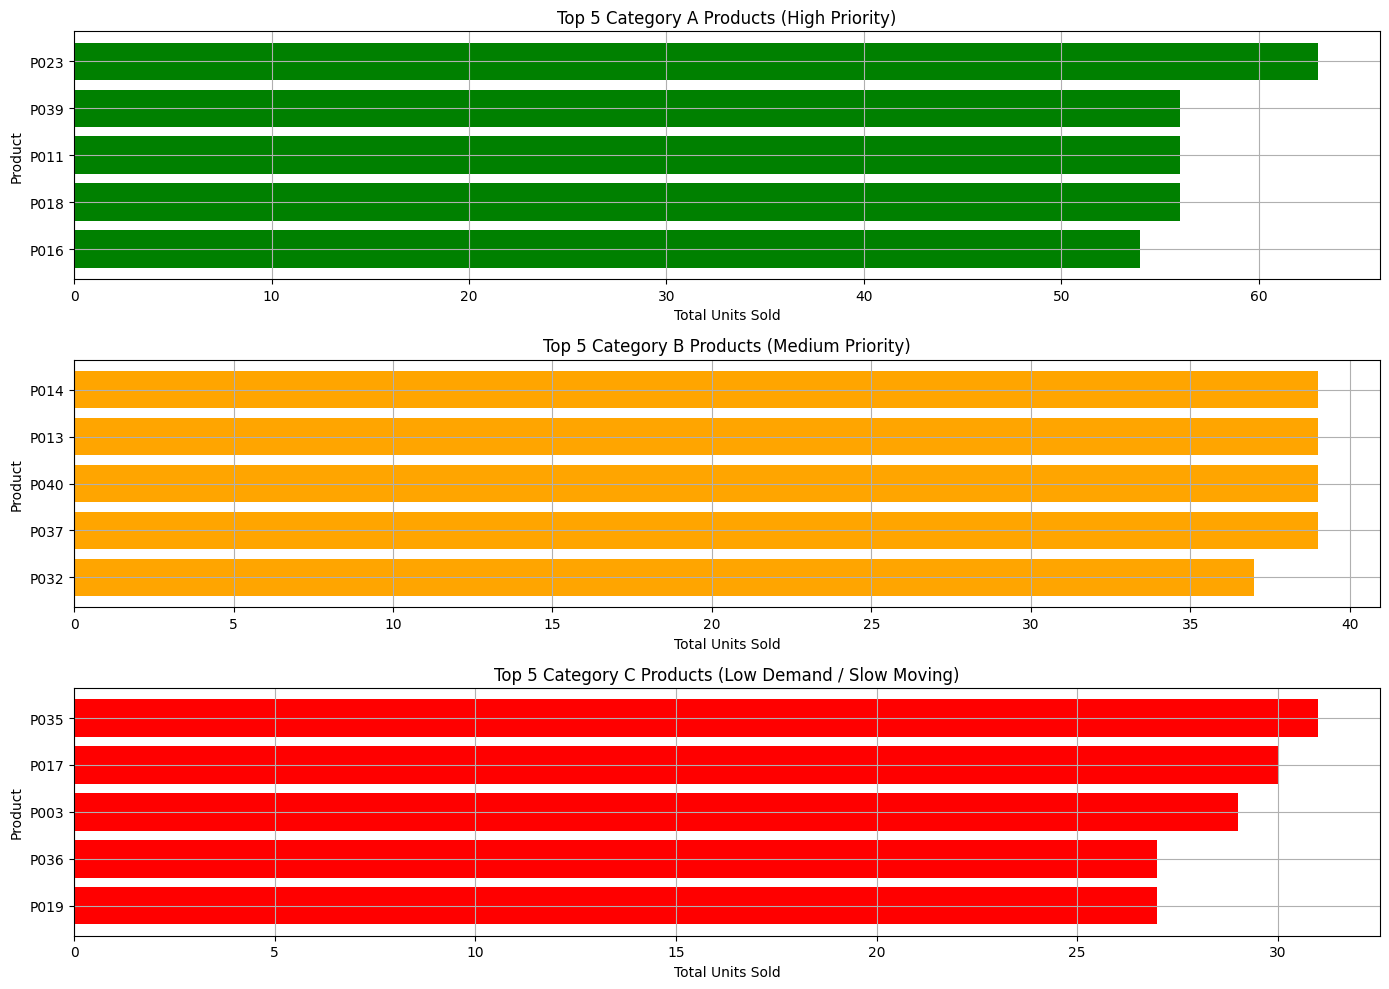

In [ ]:
import matplotlib.pyplot as plt

# Top 5 from each class
top_A = prod_sum[prod_sum["Class"]=="A"].sort_values("Quantity", ascending=False).head(5)
top_B = prod_sum[prod_sum["Class"]=="B"].sort_values("Quantity", ascending=False).head(5)
top_C = prod_sum[prod_sum["Class"]=="C"].sort_values("Quantity", ascending=False).head(5)

plt.figure(figsize=(14, 10))

# Category A
plt.subplot(3, 1, 1)
plt.barh(top_A["Product"], top_A["Quantity"], color="green")
plt.title("Top 5 Category A Products (High Priority)")
plt.xlabel("Total Units Sold")
plt.ylabel("Product")
plt.gca().invert_yaxis()

# Category B
plt.subplot(3, 1, 2)
plt.barh(top_B["Product"], top_B["Quantity"], color="orange")
plt.title("Top 5 Category B Products (Medium Priority)")
plt.xlabel("Total Units Sold")
plt.ylabel("Product")
plt.gca().invert_yaxis()

# Category C
plt.subplot(3, 1, 3)
plt.barh(top_C["Product"], top_C["Quantity"], color="red")
plt.title("Top 5 Category C Products (Low Demand / Slow Moving)")
plt.xlabel("Total Units Sold")
plt.ylabel("Product")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


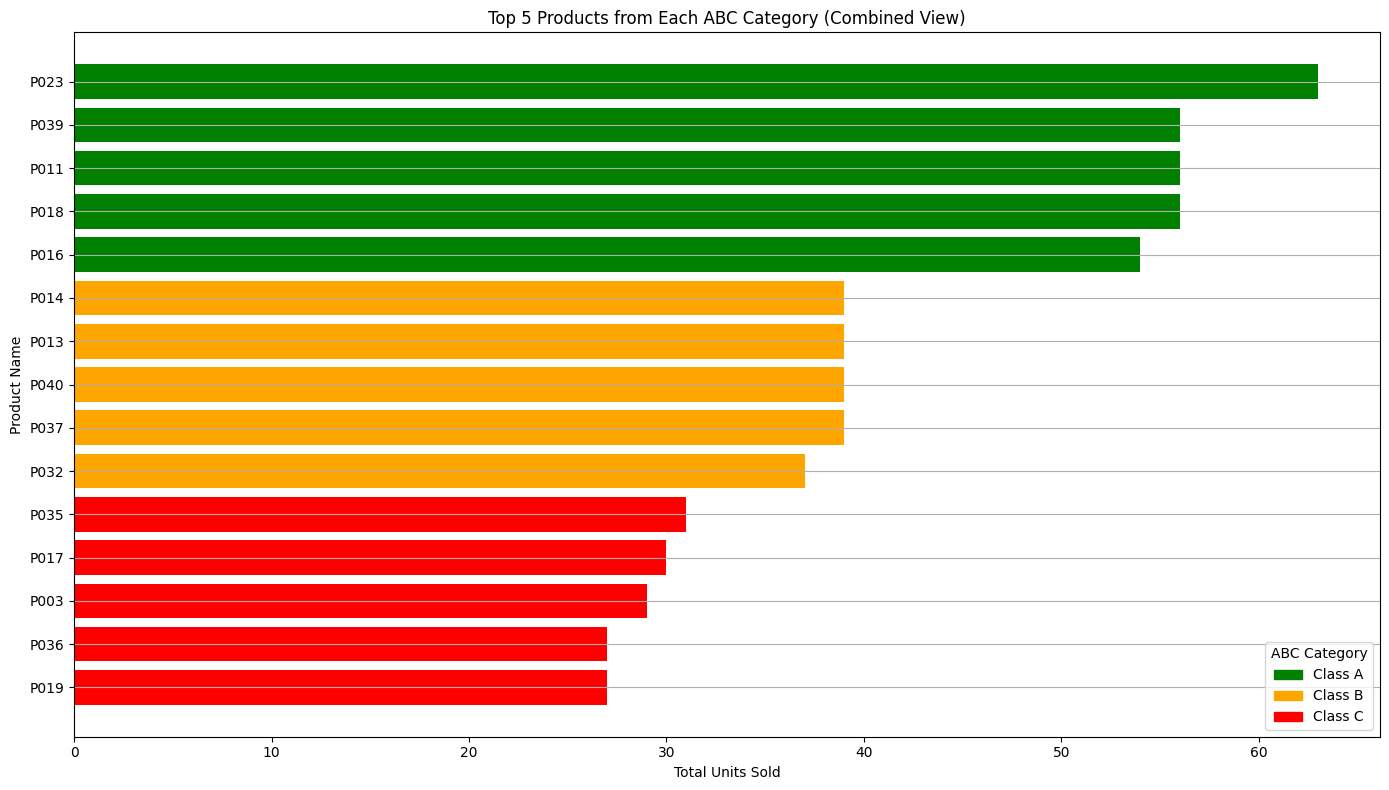

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Select top 5 from each class
top_A = prod_sum[prod_sum["Class"]=="A"].sort_values("Quantity", ascending=False).head(5)
top_B = prod_sum[prod_sum["Class"]=="B"].sort_values("Quantity", ascending=False).head(5)
top_C = prod_sum[prod_sum["Class"]=="C"].sort_values("Quantity", ascending=False).head(5)

# Combine into one dataframe
top_abc = pd.concat([top_A, top_B, top_C], axis=0)

# Colors based on class
color_map = {"A": "green", "B": "orange", "C": "red"}
colors = top_abc["Class"].map(color_map)

plt.figure(figsize=(14, 8))
plt.barh(top_abc["Product"], top_abc["Quantity"], color=colors)

plt.title("Top 5 Products from Each ABC Category (Combined View)")
plt.xlabel("Total Units Sold")
plt.ylabel("Product Name")
plt.grid(axis='x')
plt.gca().invert_yaxis()
plt.tight_layout()


legend_patches = [
    mpatches.Patch(color="green", label="Class A"),
    mpatches.Patch(color="orange", label="Class B"),
    mpatches.Patch(color="red", label="Class C")
]
plt.legend(handles=legend_patches, title="ABC Category")

plt.show()


In [ ]:
# Make sure Date is datetime
sales['Date'] = pd.to_datetime(sales['Date'], errors='coerce')

# Group into monthly totals per product
monthly_product_sales = (
    sales.groupby([pd.Grouper(key='Date', freq='MS'), 'Product'])['Quantity']
    .sum()
    .reset_index()
)

# Rename columns for clarity
monthly_product_sales.columns = ['Month', 'Product Name', 'Units Sold']

In [ ]:
top_5_products = (
    monthly_product_sales.groupby('Product Name')['Units Sold']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

top_sales_data = monthly_product_sales[monthly_product_sales['Product Name'].isin(top_5_products)]


#forecast using SARIMA (Seasonal ARIMA)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


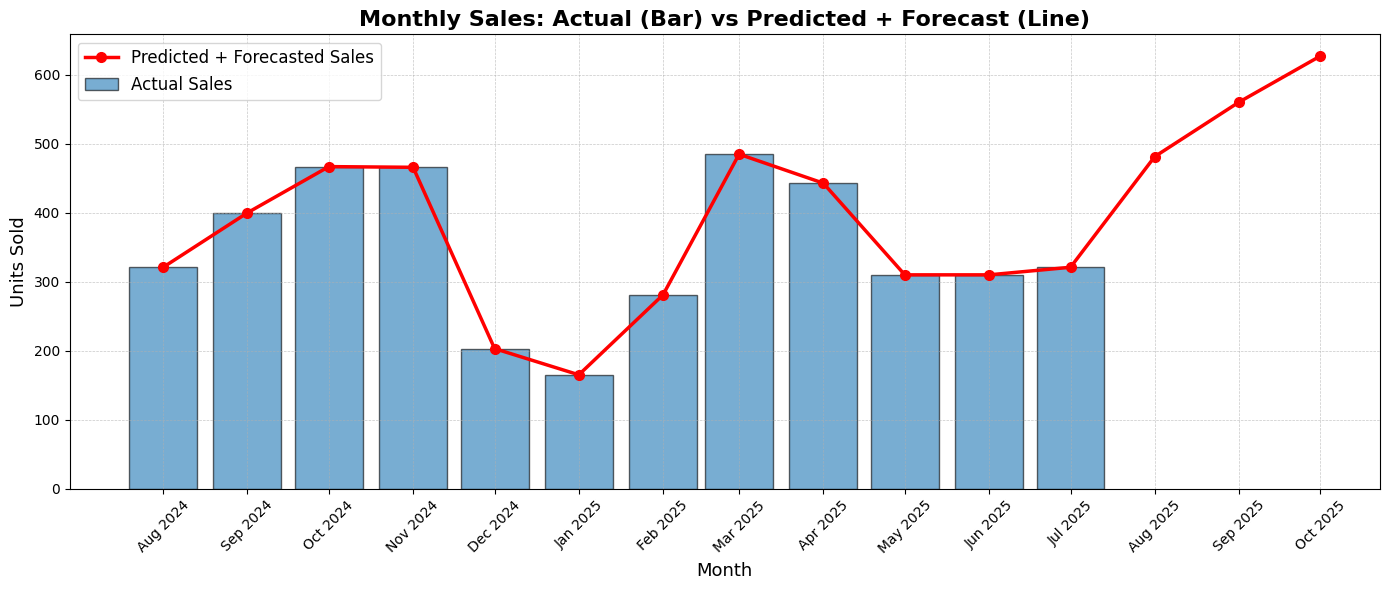


Forecast for Next 3 Months:
2025-08-01    481.50008
2025-09-01    560.50008
2025-10-01    627.50008
Freq: MS, Name: predicted_mean, dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# --------------------------------------
# 1. Load Dataset
# --------------------------------------
df = pd.read_excel("/content/BDM-DATASET.xlsx", sheet_name="Master_Sales_data")
# Convert date column to datetime
df['DATE'] = pd.to_datetime(df['Transaction_Date'], dayfirst=True)

# Monthly grouping
df['Month'] = df['DATE'].dt.to_period('M')
monthly = df.groupby('Month')['Quantity'].sum().to_timestamp()

# --------------------------------------
# 2. Fit SARIMA Model
# --------------------------------------
model = SARIMAX(monthly, order=(1,1,1), seasonal_order=(1,1,1,12))
result = model.fit(disp=False)

# --------------------------------------
# 3. Forecast Next 3 Months
# --------------------------------------
n_forecast = 3
forecast = result.get_forecast(steps=n_forecast)
forecast_mean = forecast.predicted_mean
forecast_index = pd.date_range(start=monthly.index[-1] + pd.offsets.MonthBegin(), periods=n_forecast, freq='MS')
forecast_mean.index = forecast_index

# Combine actual + forecasted predictions
full_predicted = pd.concat([monthly, forecast_mean])

# --------------------------------------
# 4. BEAUTIFUL Presentation Graph
# --------------------------------------
plt.figure(figsize=(14, 6))

# Bar chart for actual data
plt.bar(monthly.index, monthly.values,
        label='Actual Sales', alpha=0.6, width=25, edgecolor='black')

# Line chart for predicted + forecasted data
plt.plot(full_predicted.index, full_predicted.values,
         color='red', marker='o', linewidth=2.5, markersize=7,
         label='Predicted + Forecasted Sales')

# Formatting aesthetics
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# X-axis labels formatting
plt.xticks(full_predicted.index, [d.strftime('%b %Y') for d in full_predicted.index],
           rotation=45, fontsize=10)

plt.title("Monthly Sales: Actual (Bar) vs Predicted + Forecast (Line)", fontsize=16, fontweight='bold')
plt.xlabel("Month", fontsize=13)
plt.ylabel("Units Sold", fontsize=13)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Print forecast table clearly
print("\nForecast for Next 3 Months:")
print(forecast_mean)

in the above graph the actual and predection coinside exctally becuse the forecast was made for AUG 2025,SEP 2025 and OCT 2025 from the previous data

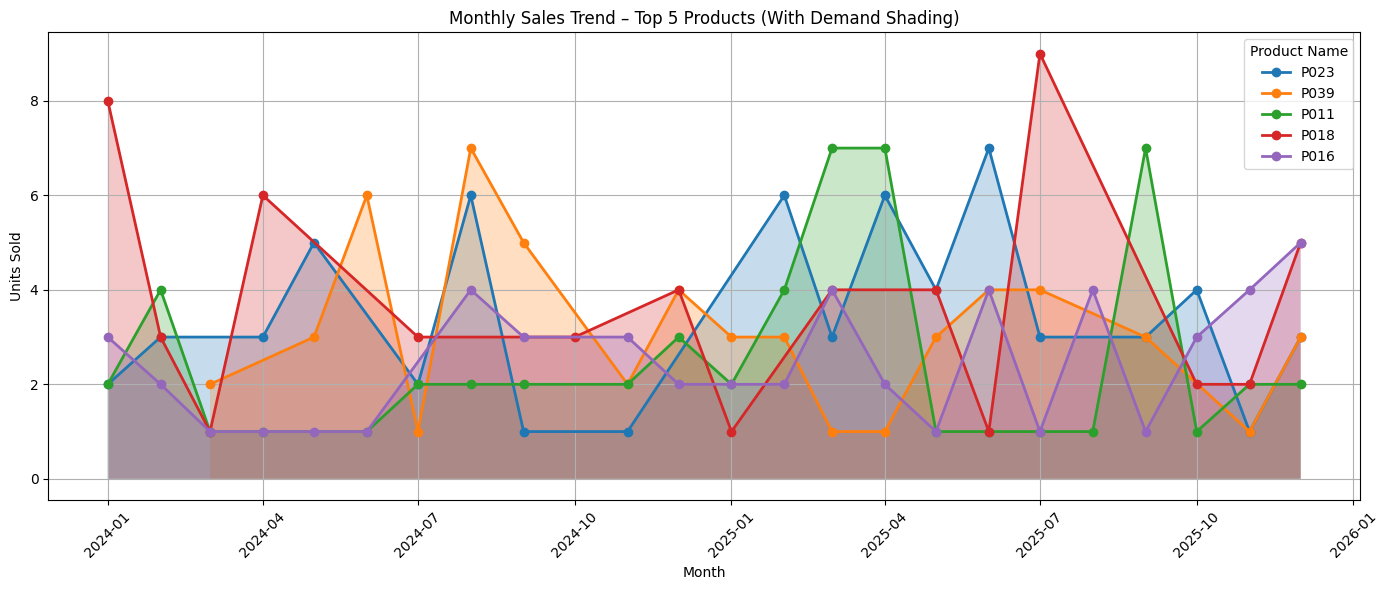

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

sales['Date'] = pd.to_datetime(sales['Date'], errors='coerce')

monthly_product_sales = (
    sales.groupby([pd.Grouper(key='Date', freq='MS'), 'Product'])['Quantity']
    .sum()
    .reset_index()
    .rename(columns={'Quantity': 'Units Sold'})
)

# Identify Top 5 Products based on total yearly sales
top_5_products = (
    monthly_product_sales.groupby("Product")["Units Sold"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

#Filter only top 5 product data
top_sales_data = monthly_product_sales[monthly_product_sales["Product"].isin(top_5_products)]

plt.figure(figsize=(14, 6))

# Plot each top product with shading
for product in top_5_products:
    product_data = top_sales_data[top_sales_data["Product"] == product].sort_values("Date")
    plt.plot(product_data["Date"], product_data["Units Sold"], marker='o', linewidth=2, label=product)
    plt.fill_between(
        product_data["Date"],
        product_data["Units Sold"],
        alpha=0.25
    )

plt.title("Monthly Sales Trend – Top 5 Products (With Demand Shading)")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title="Product Name")
plt.tight_layout()
plt.show()


In [ ]:
sales.columns


Index(['Date', 'Product', 'Quantity'], dtype='object')

/tmp/ipython-input-4247303620.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


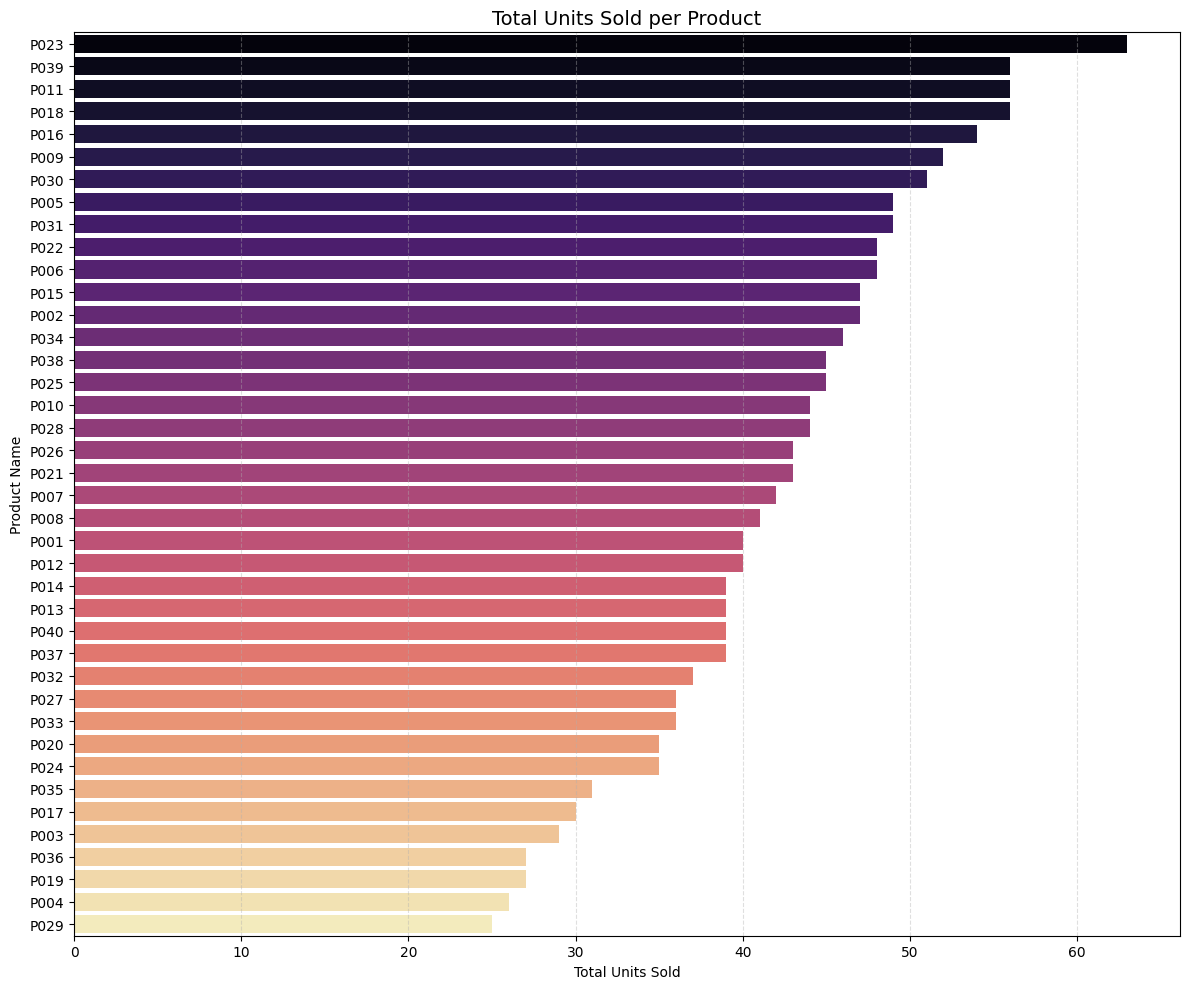

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Aggregate total units sold per product
total_sales_all_products = (
    monthly_product_sales.groupby("Product")["Units Sold"]
    .sum()
    .sort_values(ascending=False)
)

# Plot with same magma color palette
plt.figure(figsize=(12, 10))
sns.barplot(
    x=total_sales_all_products.values,
    y=total_sales_all_products.index,
    palette="magma"    # <--- Same color style
)

plt.title("Total Units Sold per Product", fontsize=14)
plt.xlabel("Total Units Sold")
plt.ylabel("Product Name")
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


#Holt’s Linear Trend Model forecasting model

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing


In [ ]:
product = pd.read_excel('/content/BDM-DATASET.xlsx', sheet_name='Product_List')
sales_month = pd.read_excel('/content/BDM-DATASET.xlsx', sheet_name='Product _Sales_MonthWise')
inventory = pd.read_excel('/content/BDM-DATASET.xlsx', sheet_name='Inventory_Data')

print("PRODUCT DATA")
display(product.head())

print("MONTH-WISE SALES DATA")
display(sales_month.head())

print("INVENTORY DATA")
display(inventory.head())

PRODUCT DATA


,Product_ID,Product,Category,Packing Size,Adjusted MRP,Adjusted Cost Price,Selling Price
0,P001,AG ONE,Biostimulant,1 Litre,980,650,800
1,P002,SAAF,Fungicide,1 kg,820,490,600
2,P003,Coragen,Insecticide,60 ml,780,560,650
3,P004,Zintara 700,Fungicide,1 Litre,1540,1020,1250
4,P005,pendamil super,Herbicide,700 ml,380,230,250


MONTH-WISE SALES DATA


,Product_ID,Product_Name,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07
0,P001,AG ONE,3,8,8,5,2,4,5,6,5,1,6,10
1,P002,SAAF,5,6,7,6,4,3,8,7,4,14,4,6
2,P003,Coragen,5,7,7,7,5,3,4,6,6,1,4,5
3,P004,Zintara 700,1,6,7,4,6,7,3,7,8,5,3,2
4,P005,pendamil super,3,8,11,7,2,4,3,7,6,3,3,4


INVENTORY DATA


,Product_ID,Product,Category,August-opening-stocks,August-sales,August-incoming,August-outgoing,August-closing-stocks,September-opening-stocks,September-sales,...,June-opening-stocks,June-sales,June-incoming,June-outgoing,June-closing-stocks,July-opening-stocks,July-sales,July-incoming,July-outgoing,July-closing-stocks
0,P001,AG ONE,Biostimulant,10,3,3,0,10,10,8,...,10,6,5,0,9,9,10,11,0,10
1,P002,SAAF,Fungicide,15,5,5,0,15,15,6,...,13,4,4,0,13,13,6,6,0,13
2,P003,Coragen,Insecticide,11,5,4,0,10,10,7,...,6,4,3,0,5,5,5,6,0,6
3,P004,Zintara 700,Fungicide,10,1,1,0,10,10,6,...,8,3,4,0,9,9,2,2,0,9
4,P005,pendamil super,Herbicide,8,3,3,0,8,8,8,...,6,3,3,0,6,6,4,4,0,6


In [ ]:
sales_long = sales_month.melt(
    id_vars=['Product_ID','Product_Name'],
    var_name='Month',
    value_name='Units_Sold'
)

merged = sales_long.merge(product, left_on='Product_Name', right_on='Product', how='left')
merged['Month'] = pd.to_datetime(merged['Month'], format='%Y-%m')

merged['Profit_per_unit'] = merged['Selling Price'] - merged['Adjusted Cost Price']
merged['Revenue'] = merged['Units_Sold'] * merged['Selling Price']
merged['Profit'] = merged['Units_Sold'] * merged['Profit_per_unit']

print("MERGED DATA (This is our main analysis table)")
display(merged.head())

MERGED DATA (This is our main analysis table)


,Product_ID_x,Product_Name,Month,Units_Sold,Product_ID_y,Product,Category,Packing Size,Adjusted MRP,Adjusted Cost Price,Selling Price,Profit_per_unit,Revenue,Profit
0,P001,AG ONE,2024-08-01,3,P001,AG ONE,Biostimulant,1 Litre,980,650,800,150,2400,450
1,P002,SAAF,2024-08-01,5,P002,SAAF,Fungicide,1 kg,820,490,600,110,3000,550
2,P003,Coragen,2024-08-01,5,P003,Coragen,Insecticide,60 ml,780,560,650,90,3250,450
3,P004,Zintara 700,2024-08-01,1,P004,Zintara 700,Fungicide,1 Litre,1540,1020,1250,230,1250,230
4,P005,pendamil super,2024-08-01,3,P005,pendamil super,Herbicide,700 ml,380,230,250,20,750,60


In [ ]:
from statsmodels.tsa.holtwinters import Holt

all_forecasts = []

unique_products = merged['Product_Name'].unique()

for product_name in unique_products:

    # Extract & group monthly sales (fix duplicate index problem)
    ts = merged[merged['Product_Name'] == product_name][['Month','Units_Sold']]
    ts = ts.groupby('Month').sum()  # <-- FIX
    ts = ts.asfreq('MS').fillna(0)  # convert to monthly index

    # Holt Linear Trend Model (correct for <24 months data)
    model = Holt(ts, exponential=False, damped_trend=True).fit()
    forecast = model.forecast(3)

    # Store forecast results
    df_temp = forecast.reset_index()
    df_temp.columns = ['Forecast_Month', 'Forecast_Units']
    df_temp['Product_Name'] = product_name

    all_forecasts.append(df_temp)

forecast_results = pd.concat(all_forecasts, ignore_index=True)

print("Forecasts Generated Successfully for ALL Products\n")
display(forecast_results)


Forecasts Generated Successfully for ALL Products



,Forecast_Month,Forecast_Units,Product_Name
0,2025-08-01,10.601690,AG ONE
1,2025-09-01,11.083042,AG ONE
2,2025-10-01,11.468124,AG ONE
3,2025-08-01,7.380074,SAAF
4,2025-09-01,7.400491,SAAF
...,...,...,...
115,2025-09-01,6.111942,VALENCIA BORON 20%
116,2025-10-01,6.207412,VALENCIA BORON 20%
117,2025-08-01,1.945024,GREEN MAGNESIUM 9.6%
118,2025-09-01,1.901044,GREEN MAGNESIUM 9.6%


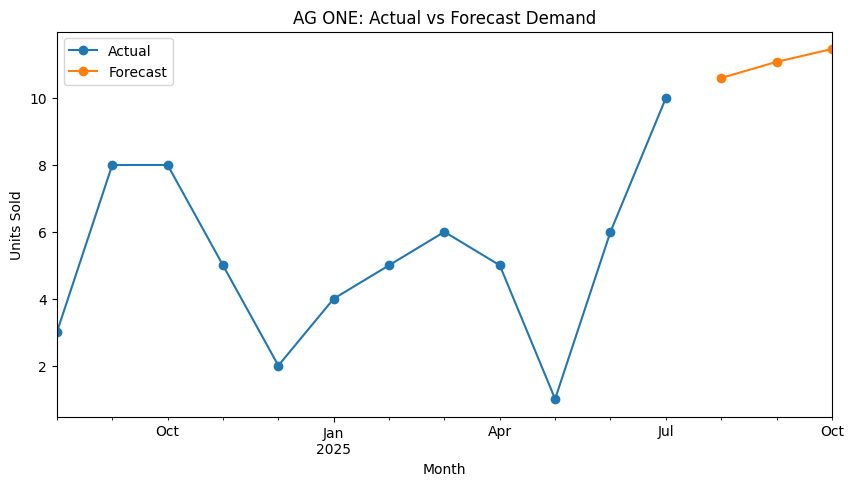

In [ ]:
p = "AG ONE"  # change product name what you want

ts = merged[merged['Product_Name'] == p][['Month','Units_Sold']]
ts = ts.set_index('Month')['Units_Sold'].asfreq('MS').fillna(0)

model = Holt(ts, exponential=False, damped_trend=True).fit()
forecast = model.forecast(3)

plt.figure(figsize=(10,5))
ts.plot(marker='o', label='Actual')
forecast.plot(marker='o', label='Forecast')
plt.title(f"{p}: Actual vs Forecast Demand")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.grid(False)
plt.legend()
plt.show()



#for top 5 products forecast

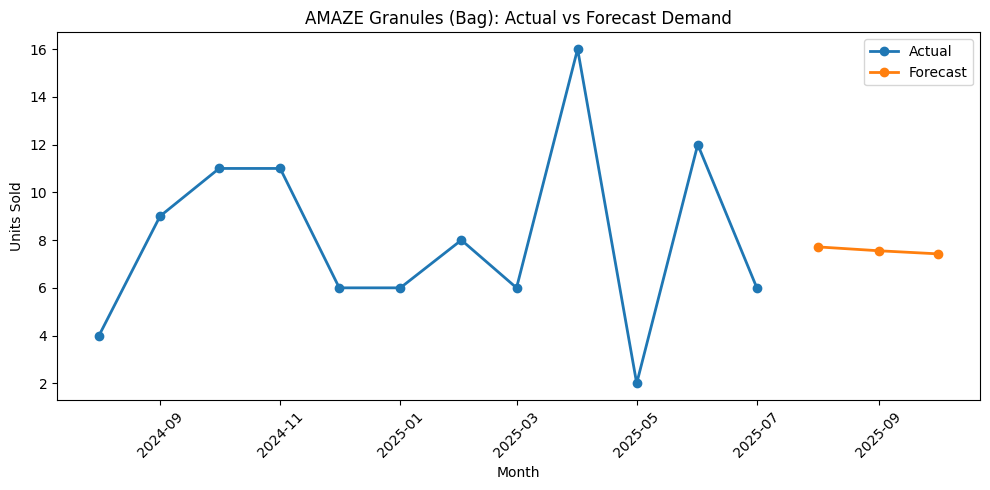

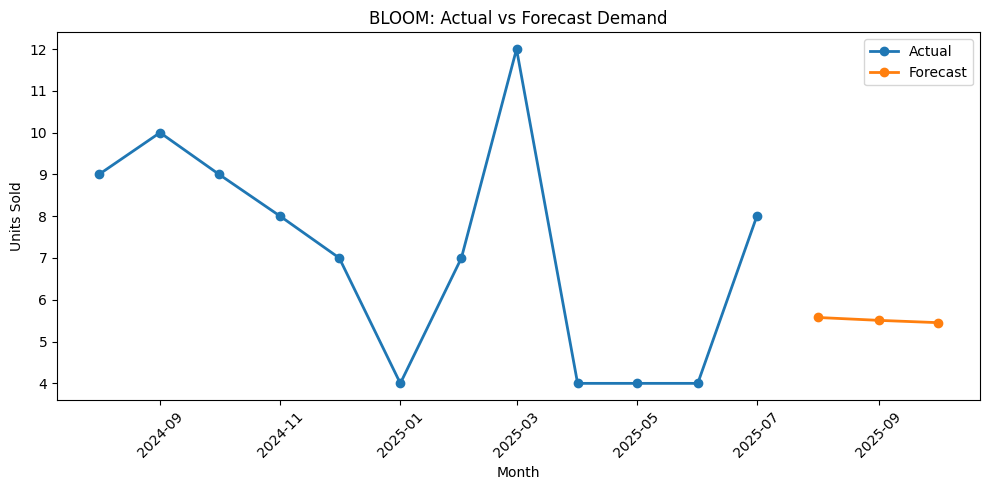

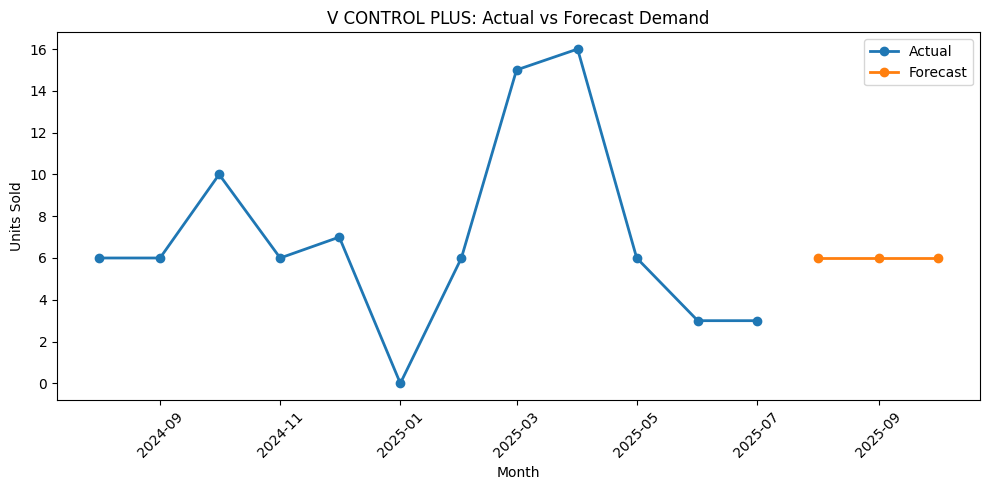

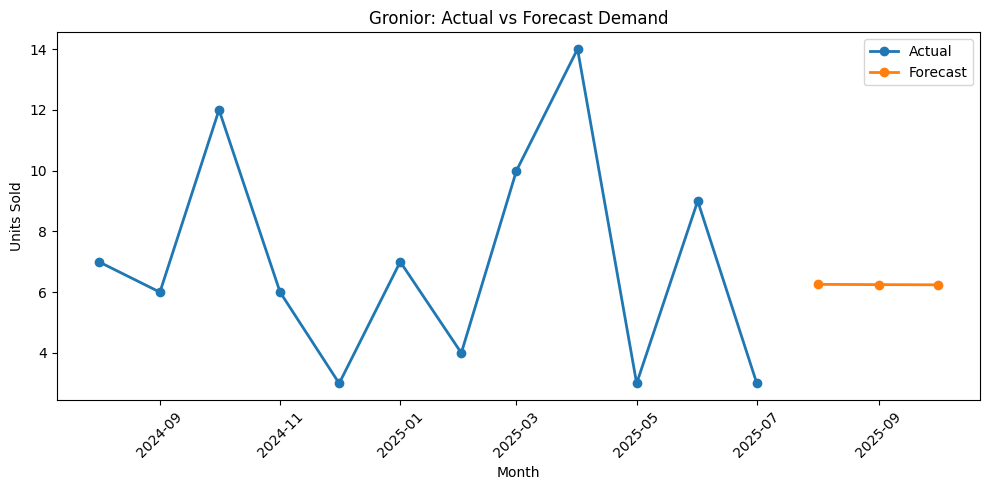

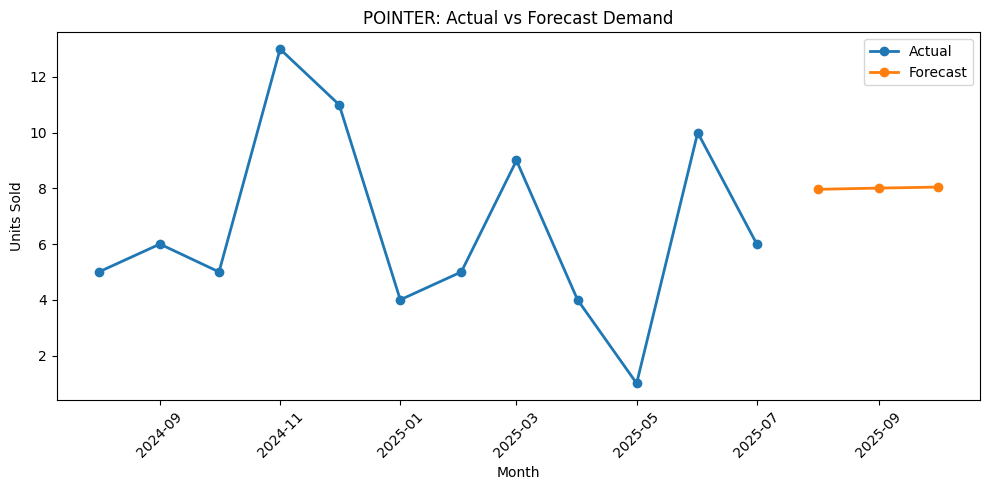

In [ ]:
from statsmodels.tsa.holtwinters import Holt
import matplotlib.pyplot as plt

# Get Top 5 Best-Selling Products
top_5_products = (
    merged.groupby("Product_Name")["Units_Sold"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

for p in top_5_products:

    #Prepare Time Series for Each Product
    ts = merged[merged['Product_Name'] == p][['Month','Units_Sold']]
    ts = ts.set_index('Month')['Units_Sold'].asfreq('MS').fillna(0)

    #Model + Forecast Next 3 Months
    model = Holt(ts, exponential=False, damped_trend=True).fit()
    forecast = model.forecast(3)

    #Plot in Your Exact Style
    plt.figure(figsize=(10,5))
    plt.plot(ts.index, ts.values, marker='o', linewidth=2, label='Actual')
    plt.plot(forecast.index, forecast.values, marker='o', linewidth=2, label='Forecast')

    plt.title(f"{p}: Actual vs Forecast Demand")
    plt.xlabel("Month")
    plt.ylabel("Units Sold")

    plt.grid(False)   # <--- No Grid (Your requirement)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
